# Replicate CDC SVI
Attempt to replicate the CDC SVI from the input variables.

This is needed because the CDRZ program uses a modified SVI without race.

## Description of Program
- program:    tu3svi2_3cv1_replicateCDC
- task:       Replicate CDC SVI 
- Version:    2024-08-27
- project:    DOE Southeast Texas Urban Field Lab SVI Paper - round 2 of analysis 
- funding:	  DOE
- author:    Nathanael Rosenheim
- GRA:        Lidia Mezei

## Control Python
Add install and add packages.

In [46]:
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd # For obtaining and cleaning spatial data
import numpy as np      # For working with arrays

import seaborn as sns
import matplotlib.pyplot as plt  # for plotting points
import os # For saving to path

In [47]:
import sys
print("Python Version     ", sys.version)
print("geopandas version: ", gpd.__version__)

Python Version      3.10.9 | packaged by conda-forge | (main, Feb  2 2023, 20:14:58) [MSC v.1929 64 bit (AMD64)]
geopandas version:  0.12.2


## Set Provenance 

In [48]:
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\Box\\SETx-UIFL_Team-folder\\Theme 3 - equity\\Text\\SVI_Analysis_Paper\\SourceData\\www_atsdr_cdc_gov_placeandhealth_svi'

In [49]:
# Store Program Name for output files to have the same name and saved in the same directory
programname = "tu3svi2_3cv1_replicateCDC_2024-08-27"
# Make directory to save output
#if not os.path.exists(programname):
#    os.mkdir(programname)

# Obtain Data
Obtain data from about each variable in SVI data.

In [50]:
obtain_program = "tu3svi2_2bv2_SetupCDC_2024-08-27"
dataset = "TRACT2020"
obtain_file = obtain_program+"_"+dataset+".csv"
svi_df = pd.read_csv(obtain_file, dtype={'TRACT2020': str})
svi_df.head()

,TRACT2020,C202010020,C202010030,C202010040,C202020010,C202020020,C202020031,C202020050,C202021010,C202030010,...,C202081010,C202090011,C202090012,C202090021,C202090022,C202090091,C202090092,C202091011,C202091012,C202092023
0,01001020100,1941,693,710,0.181,0.021,0.208,0.096,0.143,0.152,...,0.213,0.282,NaN,0.279,NaN,0.0,NaN,2.0,NaN,NaN
1,01001020200,1757,573,720,0.254,0.040,0.260,0.059,0.106,0.162,...,0.110,0.541,NaN,0.488,NaN,1.0,NaN,3.0,NaN,NaN
2,01001020300,3694,1351,1464,0.228,0.027,0.195,0.035,0.128,0.126,...,0.140,0.504,NaN,0.484,NaN,0.0,NaN,3.0,NaN,NaN
3,01001020400,3539,1636,1741,0.142,0.024,0.174,0.048,0.062,0.274,...,0.196,0.270,NaN,0.290,NaN,1.0,NaN,2.0,NaN,NaN
4,01001020501,4306,1706,1786,0.210,0.010,0.206,0.032,0.088,0.126,...,0.140,0.334,NaN,0.343,NaN,0.0,NaN,2.0,NaN,NaN


In [51]:
cdc_source_data_file = 'CDC_2020_US_Tract_2023-11-09.csv'
# Load the CDC data
cdc_df = pd.read_csv(cdc_source_data_file, dtype={'FIPS': str})

In [52]:
# compare files
svi_df['TRACT2020'].describe()

count           84122
unique          84122
top       01001020100
freq                1
Name: TRACT2020, dtype: object

In [53]:
cdc_df['FIPS'].describe()

count           84122
unique          84122
top       01001020100
freq                1
Name: FIPS, dtype: object

In [54]:
# Variables included in SVI
data_dictionary = {
    "C202020010": {"theme": "THEME1", "label": "Below 150% Poverty", "oldvarname": "EP_POV150"},
    "C202020020": {"theme": "THEME1", "label": "Unemployed", "oldvarname": "EP_UNEMP"},
    "C202020031": {"theme": "THEME1", "label": "Housing Cost Burden", "oldvarname": "EP_HBURD"},
    "C202021010": {"theme": "THEME1", "label": "No High School Diploma", "oldvarname": "EP_NOHSDP"},
    "C202020050": {"theme": "THEME1", "label": "No Health Insurance", "oldvarname": "EP_UNINSUR"},
    "C202030010": {"theme": "THEME2", "label": "Aged 65 or Older", "oldvarname": "EP_AGE65"},
    "C202033010": {"theme": "THEME2", "label": "Single-Parent Households", "oldvarname": "EP_SNGPNT"},
    "C202033020": {"theme": "THEME2", "label": "Aged 17 or Younger", "oldvarname": "EP_AGE17"},
    "C202062010": {"theme": "THEME2", "label": "English Language Proficiency", "oldvarname": "EP_LIMENG"},
    "C202081010": {"theme": "THEME2", "label": "Civilian With a Disability", "oldvarname": "EP_DISABL"},
    "C202060010": {"theme": "THEME3", "label": "Minority", "oldvarname": "EP_MINRTY"},
    "C202070010": {"theme": "THEME4", "label": "Mobile Homes", "oldvarname": "EP_MOBILE"},
    "C202070020": {"theme": "THEME4", "label": "Group Quarters", "oldvarname": "EP_GROUPQ"},
    "C202070050": {"theme": "THEME4", "label": "Multi-Unit Structures", "oldvarname": "EP_MUNIT"},
    "C202070055": {"theme": "THEME4", "label": "Crowding", "oldvarname": "EP_CROWD"},
    "C202072010": {"theme": "THEME4", "label": "No Vehicle", "oldvarname": "EP_NOVEH"}
}


In [55]:
# replace missing values with NaN
svi_df.replace(-999, np.nan, inplace=True)
cdc_df.replace(-999, np.nan, inplace=True)


In [56]:
cdc_df['E_UNINSUR'].describe()

count    84122.000000
mean       333.550118
std        330.683579
min          0.000000
25%        115.000000
50%        234.000000
75%        439.000000
max       5274.000000
Name: E_UNINSUR, dtype: float64

In [57]:
check_svi_df = svi_df.copy()
check_cdc_df = cdc_df.copy()

# Loop over the dictionary to compare variables
for key, value in data_dictionary.items():
    newvarname = key
    oldvarname = value['oldvarname']
    
    # Ensure both columns exist in the DataFrames
    if newvarname in svi_df.columns and oldvarname in cdc_df.columns:
        # Get the descriptive statistics for both variables
        check_svi_df[newvarname] = check_svi_df[newvarname] * 100
        svi_describe = check_svi_df[newvarname].describe().T
        cdc_describe = check_cdc_df[oldvarname].describe().T
        
        # Stack the two series to compare
        comparison = pd.concat([svi_describe, cdc_describe], axis=1)
        
        # add column to compare the difference
        comparison['difference'] = comparison[newvarname] - comparison[oldvarname]
        # round the difference to 2 decimal places
        comparison['difference'] = comparison['difference'].round(2)

        # Optionally, add column names for clarity
        comparison.columns = [newvarname, oldvarname, 'difference']
        
        # Print or store the comparison result
        print(f"Comparison between {newvarname} and {oldvarname}:")
        print(comparison)
        print("\n")
    else:
        print(f"One or both columns {newvarname} and {oldvarname} not found in the DataFrames")
        

Comparison between C202020010 and EP_POV150:
         C202020010     EP_POV150  difference
count  84122.000000  84122.000000         0.0
mean      22.260361     22.260361         0.0
std       15.451197     15.451197         0.0
min        0.000000      0.000000         0.0
25%       10.400000     10.400000         0.0
50%       18.900000     18.900000         0.0
75%       30.800000     30.800000         0.0
max      100.000000    100.000000         0.0


Comparison between C202020020 and EP_UNEMP:
         C202020020      EP_UNEMP  difference
count  83455.000000  83455.000000         0.0
mean       5.723942      5.723942         0.0
std        4.724210      4.724210         0.0
min        0.000000      0.000000         0.0
25%        2.700000      2.700000         0.0
50%        4.600000      4.600000         0.0
75%        7.500000      7.500000         0.0
max      100.000000    100.000000         0.0


Comparison between C202020031 and EP_HBURD:
         C202020031      EP_HBURD  

### Replicate how the CDC calculates SVI score
The CDC takes the percentile rank of each variable, sums these up, and then takes the percentile rank of the sum.

In [58]:
# loop over the data_dictionary and create a new column with the percentile rank
for key, value in data_dictionary.items():


    print(key, value)
    svi_df[key+"_PCT"] = svi_df[key].rank(pct=True)

    # add rank that is not percent
    svi_df[key+"_rank"] = svi_df[key].rank()


    # keep the percentile rank to 4 decimal places
    svi_df[key+"_PCT"] = svi_df[key+"_PCT"].apply(lambda x: round(x, 4))

    # replace PCT variable with 0 if the original variable is 0
    svi_df[key+"_PCT"] = np.where(svi_df[key] == 0, 0, svi_df[key+"_PCT"])



C202020010 {'theme': 'THEME1', 'label': 'Below 150% Poverty', 'oldvarname': 'EP_POV150'}
C202020020 {'theme': 'THEME1', 'label': 'Unemployed', 'oldvarname': 'EP_UNEMP'}
C202020031 {'theme': 'THEME1', 'label': 'Housing Cost Burden', 'oldvarname': 'EP_HBURD'}
C202021010 {'theme': 'THEME1', 'label': 'No High School Diploma', 'oldvarname': 'EP_NOHSDP'}
C202020050 {'theme': 'THEME1', 'label': 'No Health Insurance', 'oldvarname': 'EP_UNINSUR'}
C202030010 {'theme': 'THEME2', 'label': 'Aged 65 or Older', 'oldvarname': 'EP_AGE65'}
C202033010 {'theme': 'THEME2', 'label': 'Single-Parent Households', 'oldvarname': 'EP_SNGPNT'}
C202033020 {'theme': 'THEME2', 'label': 'Aged 17 or Younger', 'oldvarname': 'EP_AGE17'}
C202062010 {'theme': 'THEME2', 'label': 'English Language Proficiency', 'oldvarname': 'EP_LIMENG'}
C202081010 {'theme': 'THEME2', 'label': 'Civilian With a Disability', 'oldvarname': 'EP_DISABL'}
C202060010 {'theme': 'THEME3', 'label': 'Minority', 'oldvarname': 'EP_MINRTY'}
C202070010 {'t

In [59]:
# Identify columns that end with "_PCT"
PCT_vars = [col for col in svi_df.columns if col.endswith("_PCT")]
svi_df[PCT_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
C202020010_PCT,84122.0,0.499941,0.288788,0.0,0.2499,0.4988,0.7498,0.9997
C202020020_PCT,83455.0,0.499643,0.289285,0.0,0.2553,0.4994,0.7531,1.0000
C202020031_PCT,84122.0,0.499946,0.288779,0.0,0.2499,0.5009,0.7492,0.9998
C202021010_PCT,83576.0,0.499906,0.288846,0.0,0.2489,0.4977,0.7510,1.0000
C202020050_PCT,83454.0,0.499948,0.288773,0.0,0.2525,0.4981,0.7486,1.0000
C202030010_PCT,83598.0,0.499994,0.288696,0.0,0.2507,0.5009,0.7493,0.9999
C202033010_PCT,84122.0,0.498072,0.291852,0.0,0.2540,0.5023,0.7494,1.0000
C202033020_PCT,84122.0,0.499935,0.288795,0.0,0.2519,0.4970,0.7480,1.0000
C202062010_PCT,84122.0,0.471443,0.326371,0.0,0.2508,0.5068,0.7491,1.0000
C202081010_PCT,83454.0,0.500005,0.288674,0.0,0.2472,0.4992,0.7482,0.9999


In [60]:

# Take the sum of the percentile ranks for the identified columns
svi_df["PCT_sum"] = svi_df[PCT_vars].sum(axis=1)

# take the percentile rank of the sum of the percentile ranks
svi_df["SVI_replication"] = svi_df["PCT_sum"].rank(pct=True)

In [61]:
svi_df.head()

,TRACT2020,C202010020,C202010030,C202010040,C202020010,C202020020,C202020031,C202020050,C202021010,C202030010,...,C202070020_PCT,C202070020_rank,C202070050_PCT,C202070050_rank,C202070055_PCT,C202070055_rank,C202072010_PCT,C202072010_rank,PCT_sum,SVI_replication
0,01001020100,1941,693,710,0.181,0.021,0.208,0.096,0.143,0.152,...,0.0000,18019.0,0.0000,11246.0,0.0000,10437.0,0.1929,16076.5,6.2734,0.284688
1,01001020200,1757,573,720,0.254,0.040,0.260,0.059,0.106,0.162,...,0.9574,80535.5,0.2890,24307.5,0.4923,41416.5,0.7399,61674.0,7.9544,0.545743
2,01001020300,3694,1351,1464,0.228,0.027,0.195,0.035,0.128,0.126,...,0.0000,18019.0,0.3997,33623.5,0.6153,51763.0,0.3697,30811.5,7.7161,0.508511
3,01001020400,3539,1636,1741,0.142,0.024,0.174,0.048,0.062,0.274,...,0.0000,18019.0,0.6152,51755.5,0.3174,26701.0,0.4766,39726.5,6.2195,0.277264
4,01001020501,4306,1706,1786,0.210,0.010,0.206,0.032,0.088,0.126,...,0.5619,47264.5,0.4684,39404.5,0.0000,10437.0,0.3220,26840.0,6.6641,0.343008


In [62]:
# describe PCT vars
svi_df.describe().T

,count,mean,std,min,25%,50%,75%,max
C202010020,84122.0,3882.091581,1657.514889,0.000000,2704.000000,3727.00000,4888.000000,39373.0000
C202010030,84122.0,1454.485378,606.484129,0.000000,1031.000000,1405.00000,1827.000000,8078.0000
C202010040,84122.0,1645.618875,672.645603,0.000000,1189.000000,1589.00000,2044.000000,13037.0000
C202020010,84122.0,0.222604,0.154512,0.000000,0.104000,0.18900,0.308000,1.0000
C202020020,83455.0,0.057239,0.047242,0.000000,0.027000,0.04600,0.075000,1.0000
...,...,...,...,...,...,...,...,...
C202070055_rank,84122.0,42061.500000,24096.614752,10437.000000,21090.500000,42593.00000,63319.500000,84121.5000
C202072010_PCT,83351.0,0.497039,0.293483,0.000000,0.248600,0.49870,0.750800,0.9999
C202072010_rank,83351.0,41676.000000,24055.444519,3209.000000,20720.500000,41566.50000,62579.500000,83343.5000
PCT_sum,84122.0,7.675793,2.327690,0.000000,6.026125,7.66145,9.399875,14.3409


In [63]:
# compare variables
comp_vars = ['C202090011','SVI_replication']
svi_df[comp_vars].head()

,C202090011,SVI_replication
0,0.282,0.284688
1,0.541,0.545743
2,0.504,0.508511
3,0.270,0.277264
4,0.334,0.343008


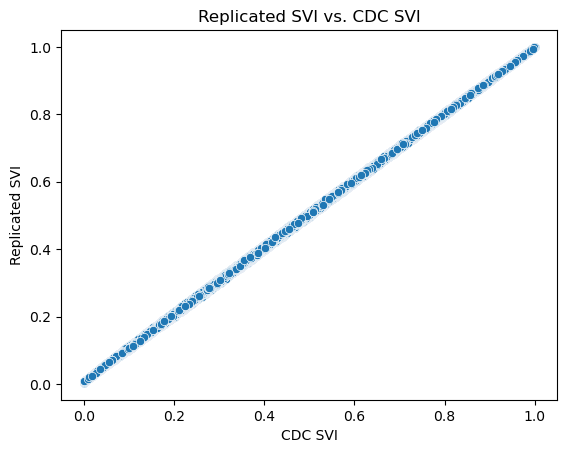

In [64]:
# scatter plot
sns.scatterplot(x='C202090011', y='SVI_replication', data=svi_df)
plt.title("Replicated SVI vs. CDC SVI")
plt.xlabel("CDC SVI")
plt.ylabel("Replicated SVI")
plt.show()

### Check why replication is not perfect
Look at EPL values in the original CDC SVI and the replication.

In [65]:
# start empty dictionary to store comparison
comparison = {}

# loop over the data_dictionary and describe the variables
for key, value in data_dictionary.items():
    svi_describe = svi_df[key+"_PCT"].describe().T
    # describe for EPL var
    EPL_var = value['oldvarname'].replace("EP_", "EPL_")
    cdc_describe = cdc_df[EPL_var].describe().T

    # concatenate the two series
    comparison[key] = pd.concat([svi_describe, cdc_describe], axis=1)

    # rotate comparison
    comparison[key] = comparison[key].T

# concatenate the comparison dictionary
comparison_df = pd.concat(comparison)

In [66]:
comparison_df 

count      mean       std  min     25%     50%  \
C202020010 C202020010_PCT  84122.0  0.499941  0.288788  0.0  0.2499  0.4988   
           EPL_POV150      83598.0  0.498904  0.289044  0.0  0.2496  0.4996   
C202020020 C202020020_PCT  83455.0  0.499643  0.289285  0.0  0.2553  0.4994   
           EPL_UNEMP       83455.0  0.495384  0.290474  0.0  0.2487  0.4939   
C202020031 C202020031_PCT  84122.0  0.499946  0.288779  0.0  0.2499  0.5009   
           EPL_HBURD       83598.0  0.498775  0.288946  0.0  0.2470  0.4995   
C202021010 C202021010_PCT  83576.0  0.499906  0.288846  0.0  0.2489  0.4977   
           EPL_NOHSDP      83576.0  0.497936  0.289630  0.0  0.2457  0.4953   
C202020050 C202020050_PCT  83454.0  0.499948  0.288773  0.0  0.2525  0.4981   
           EPL_UNINSUR     83454.0  0.497237  0.289808  0.0  0.2484  0.4948   
C202030010 C202030010_PCT  83598.0  0.499994  0.288696  0.0  0.2507  0.5009   
           EPL_AGE65       83598.0  0.498042  0.288914  0.0  0.2484  0.4983   
C202033010 C202033010_PCT  84122.0  0.498072  0.291852  0.0  0.2540  0.5023   
           EPL_SNGPNT      83598.0  0.495200  0.292091  0.0  0.2437  0.4947   
C202033020 C202033020_PCT  84122.0  0.499935  0.288795  0.0  0.2519  0.4970   
           EPL_AGE17       83598.0  0.497870  0.288668  0.0  0.2493  0.4970   
C202062010 C202062010_PCT  84122.0  0.471443  0.326371  0.0  0.2508  0.5068   
           EPL_LIMENG      83598.0  0.467956  0.325757  0.0  0.2343  0.4962   
C202081010 C202081010_PCT  83454.0  0.500005  0.288674  0.0  0.2472  0.4992   
           EPL_DISABL      83454.0  0.497534  0.289109  0.0  0.2440  0.4957   
C202060010 C202060010_PCT  84122.0  0.499967  0.288739  0.0  0.2496  0.4999   
           EPL_MINRTY      83598.0  0.499376  0.288914  0.0  0.2496  0.4994   
C202070010 C202070010_PCT  83372.0  0.394551  0.381290  0.0  0.0000  0.5046   
           EPL_MOBILE      83359.0  0.393590  0.380786  0.0  0.0000  0.4976   
C202070020 C202070020_PCT  84122.0  0.408247  0.374736  0.0  0.0000  0.5112   
           EPL_GROUPQ      83598.0  0.403521  0.371506  0.0  0.0000  0.4787   
C202070050 C202070050_PCT  84122.0  0.464264  0.333809  0.0  0.0000  0.5015   
           EPL_MUNIT       83598.0  0.464356  0.332650  0.0  0.0000  0.4965   
C202070055 C202070055_PCT  84122.0  0.469224  0.328742  0.0  0.2507  0.5063   
           EPL_CROWD       83598.0  0.466668  0.327340  0.0  0.2486  0.4962   
C202072010 C202072010_PCT  83351.0  0.497039  0.293483  0.0  0.2486  0.4987   
           EPL_NOVEH       83351.0  0.494255  0.294633  0.0  0.2429  0.4952   

                              75%     max  
C202020010 C202020010_PCT  0.7498  0.9997  
           EPL_POV150      0.7490  0.9994  
C202020020 C202020020_PCT  0.7531  1.0000  
           EPL_UNEMP       0.7499  1.0000  
C202020031 C202020031_PCT  0.7492  0.9998  
           EPL_HBURD       0.7486  0.9996  
C202021010 C202021010_PCT  0.7510  1.0000  
           EPL_NOHSDP      0.7497  1.0000  
C202020050 C202020050_PCT  0.7486  1.0000  
           EPL_UNINSUR     0.7468  1.0000  
C202030010 C202030010_PCT  0.7493  0.9999  
           EPL_AGE65       0.7473  0.9999  
C202033010 C202033010_PCT  0.7494  1.0000  
           EPL_SNGPNT      0.7455  1.0000  
C202033020 C202033020_PCT  0.7480  1.0000  
           EPL_AGE17       0.7490  1.0000  
C202062010 C202062010_PCT  0.7491  1.0000  
           EPL_LIMENG      0.7495  1.0000  
C202081010 C202081010_PCT  0.7482  0.9999  
           EPL_DISABL      0.7460  0.9999  
C202060010 C202060010_PCT  0.7498  0.9979  
           EPL_MINRTY      0.7497  0.9959  
C202070010 C202070010_PCT  0.7505  1.0000  
           EPL_MOBILE      0.7495  0.9999  
C202070020 C202070020_PCT  0.7452  0.9985  
           EPL_GROUPQ      0.7485  0.9971  
C202070050 C202070050_PCT  0.7497  0.9996  
           EPL_MUNIT       0.7500  0.9992  
C202070055 C202070055_PCT  0.7527  1.0000  
           EPL_CROWD       0.7481  1.0000  
C202072010 C202072010_PCT  0.7508  0.9999  
           EP

<AxesSubplot: ylabel='Frequency'>

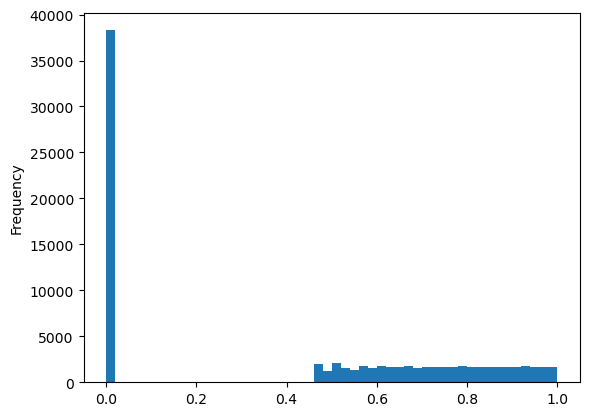

In [67]:
svi_df['C202070010_PCT'].plot(kind='hist', bins=50)

<AxesSubplot: ylabel='Frequency'>

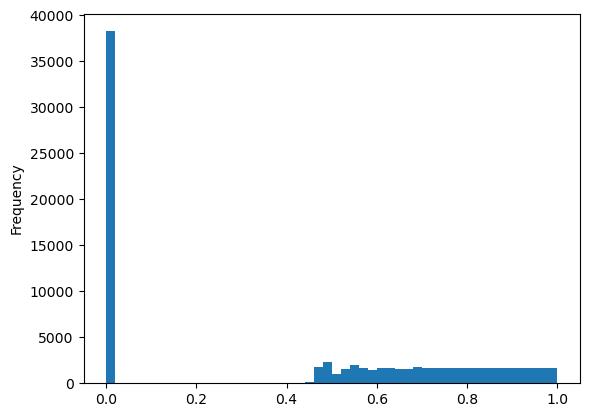

In [68]:
cdc_df['EPL_MOBILE'].plot(kind='hist', bins=50)

In [69]:
# keep PCT columns in replicated SVI
PCT_cols = [col for col in svi_df.columns if col.endswith("_PCT")]
keep_cols = ['TRACT2020'] + PCT_cols
svi_df_PCT = svi_df[keep_cols]
# merge the CDC data with the replicated SVI
merged_df = pd.merge(cdc_df, svi_df, left_on='FIPS', right_on='TRACT2020', how='inner')
merged_df.head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,C202070020_PCT,C202070020_rank,C202070050_PCT,C202070050_rank,C202070055_PCT,C202070055_rank,C202072010_PCT,C202072010_rank,PCT_sum,SVI_replication
0,1,Alabama,AL,1001,Autauga,01001020100,"Census Tract 201, Autauga County, Alabama",3.793570,1941,390,...,0.0000,18019.0,0.0000,11246.0,0.0000,10437.0,0.1929,16076.5,6.2734,0.284688
1,1,Alabama,AL,1001,Autauga,01001020200,"Census Tract 202, Autauga County, Alabama",1.282174,1757,310,...,0.9574,80535.5,0.2890,24307.5,0.4923,41416.5,0.7399,61674.0,7.9544,0.545743
2,1,Alabama,AL,1001,Autauga,01001020300,"Census Tract 203, Autauga County, Alabama",2.065364,3694,570,...,0.0000,18019.0,0.3997,33623.5,0.6153,51763.0,0.3697,30811.5,7.7161,0.508511
3,1,Alabama,AL,1001,Autauga,01001020400,"Census Tract 204, Autauga County, Alabama",2.464984,3539,500,...,0.0000,18019.0,0.6152,51755.5,0.3174,26701.0,0.4766,39726.5,6.2195,0.277264
4,1,Alabama,AL,1001,Autauga,01001020501,"Census Tract 205.01, Autauga County, Alabama",2.395243,4306,662,...,0.5619,47264.5,0.4684,39404.5,0.0000,10437.0,0.3220,26840.0,6.6641,0.343008


In [70]:
comp_vars = ['EP_UNINSUR','C202020050','EPL_UNINSUR', 'C202020050_PCT']
merged_df[comp_vars].head()

,EP_UNINSUR,C202020050,EPL_UNINSUR,C202020050_PCT
0,9.6,0.096,0.6529,0.6552
1,5.9,0.059,0.4320,0.4355
2,3.5,0.035,0.2399,0.2441
3,4.8,0.048,0.3486,0.3527
4,3.2,0.032,0.2142,0.2183


In [71]:
# count observations for comp_vars
merged_df[comp_vars].count()

EP_UNINSUR        83454
C202020050        83454
EPL_UNINSUR       83454
C202020050_PCT    83454
dtype: int64

In [72]:
comp_vars = ['EPL_POV150', 'C202020010_PCT']
# correlation
merged_df[comp_vars].corr()

,EPL_POV150,C202020010_PCT
EPL_POV150,1.000000,0.999998
C202020010_PCT,0.999998,1.000000


In [73]:
# Loop over the data dictionary and calculate correlations
for key, value in data_dictionary.items():
    # Construct the variable names
    newvarname_pct = f"{key}_PCT"
    oldvarname_epl = value['oldvarname'].replace("EP_", "EPL_")
    
    # Ensure both columns are in the DataFrame
    if newvarname_pct in merged_df.columns and oldvarname_epl in merged_df.columns:
        # Create a list of variables to compare
        comp_vars = [oldvarname_epl, newvarname_pct]
        
        # Calculate and print the correlation
        correlation = merged_df[comp_vars].corr().iloc[0, 1]
        print(f"Correlation between {oldvarname_epl} and {newvarname_pct}: {correlation}")
    else:
        print(f"One or both columns {oldvarname_epl} and {newvarname_pct} not found in DataFrame")

Correlation between EPL_POV150 and C202020010_PCT: 0.9999975156160016
Correlation between EPL_UNEMP and C202020020_PCT: 0.9999809570555197
Correlation between EPL_HBURD and C202020031_PCT: 0.999997006154432
Correlation between EPL_NOHSDP and C202021010_PCT: 0.9999975711307767
Correlation between EPL_UNINSUR and C202020050_PCT: 0.9999956485178741
Correlation between EPL_AGE65 and C202030010_PCT: 0.9999959685167041
Correlation between EPL_SNGPNT and C202033010_PCT: 0.9999569677494011
Correlation between EPL_AGE17 and C202033020_PCT: 0.9999918807659329
Correlation between EPL_LIMENG and C202062010_PCT: 0.9997837555616093
Correlation between EPL_DISABL and C202081010_PCT: 0.9999947758020283
Correlation between EPL_MINRTY and C202060010_PCT: 0.9999990231167908
Correlation between EPL_MOBILE and C202070010_PCT: 0.999990787002047
Correlation between EPL_GROUPQ and C202070020_PCT: 0.9996192185323922
Correlation between EPL_MUNIT and C202070050_PCT: 0.9999633828138161
Correlation between EPL_CR

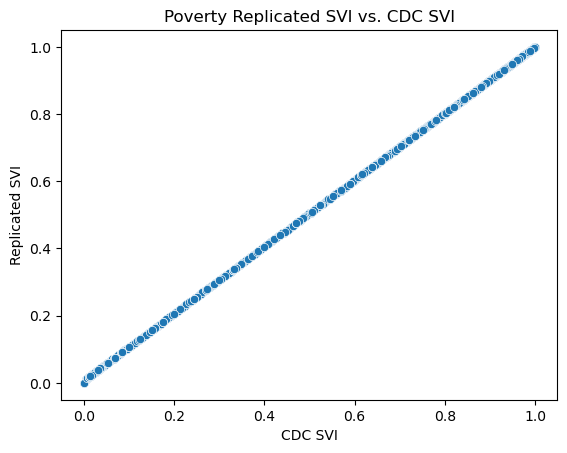

In [74]:
# compare EPL POV150 to replicated SVI C202020010_PCT
sns.scatterplot(x='EPL_POV150', y='C202020010_PCT', data=merged_df)
plt.title("Poverty Replicated SVI vs. CDC SVI")
plt.xlabel("CDC SVI")
plt.ylabel("Replicated SVI")
plt.show()

In [75]:
# correlation between EPL_GROUPQ and C202072010_PCT


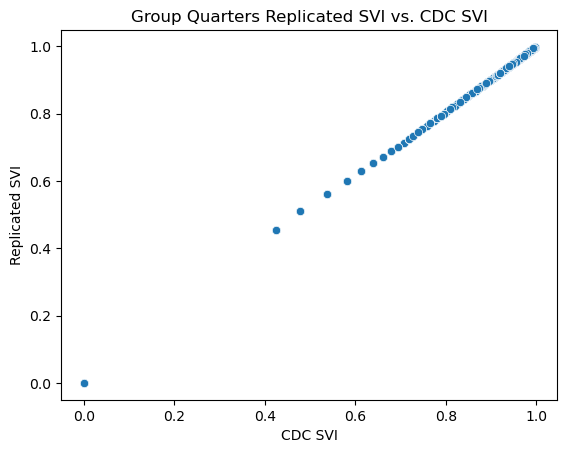

In [76]:
# compare group quarters
sns.scatterplot(x='EPL_GROUPQ', y='C202070020_PCT', data=merged_df)
plt.title("Group Quarters Replicated SVI vs. CDC SVI")
plt.xlabel("CDC SVI")
plt.ylabel("Replicated SVI")
plt.show()

# compare EPL_GROUPQ and C202072010_PCT
sns.scatterplot(x='EPL_GROUPQ', y='C202072010_PCT', data=merged_df)
plt.title("CDC SVI vs. Replicated SVI")
plt.xlabel("CDC SVI")
plt.ylabel("Replicated SVI")
plt.show()

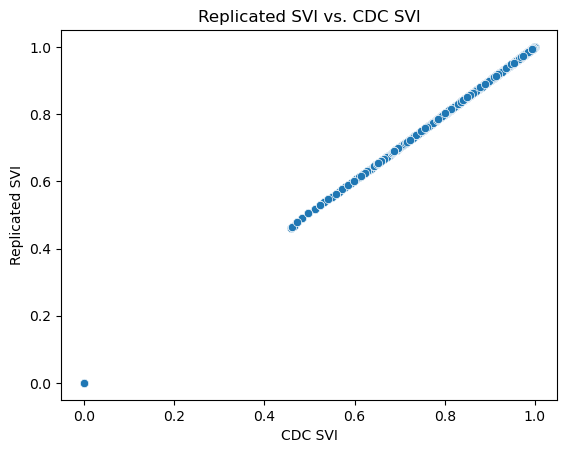

In [77]:
# compare EPL POV150 to replicated SVI C202020010_PCT
sns.scatterplot(x='EPL_MOBILE', y='C202070010_PCT', data=merged_df)
plt.title("Replicated SVI vs. CDC SVI")
plt.xlabel("CDC SVI")
plt.ylabel("Replicated SVI")
plt.show()

### Explore: How are tied values handled for percentile rank?

In [78]:
# For EP_POV150 what is the most common value
mode = cdc_df['EP_POV150'].mode()
# For EP_POV150 what is the most common value
condition = cdc_df['EP_POV150'] == mode[0]
mode_count = cdc_df[condition].shape[0]
print(f"The most common value for EP_POV150 is {mode[0]} with {mode_count} observations")

# what is the min for the above condition
min_val = cdc_df[condition]['EPL_POV150'].min()
max_val = cdc_df[condition]['EPL_POV150'].max()
print(f"The min value for {mode[0]}  EPL_POV150 is {min_val}")
print(f"The max value for {mode[0]}  EPL_POV150 is {max_val}")

# what is the next most common value greater than 0
condition = cdc_df['EP_POV150'] > 0
mode = cdc_df[condition]['EP_POV150'].mode()
condition = cdc_df['EP_POV150'] == mode[0]
mode_count = cdc_df[condition].shape[0]
print(f"The most common value for EP_POV150 greater than 0 is {mode[0]} with {mode_count} observations")

# what is the min for the above condition
min_val = cdc_df[condition]['EPL_POV150'].min()
max_val = cdc_df[condition]['EPL_POV150'].max()
print(f"The min value for {mode[0]}  EPL_POV150 is {min_val}")
print(f"The max value for {mode[0]}  EPL_POV150 is {max_val}")

The most common value for EP_POV150 is 0.0 with 957 observations
The min value for 0.0  EPL_POV150 is 0.0
The max value for 0.0  EPL_POV150 is 0.0
The most common value for EP_POV150 greater than 0 is 11.0 with 307 observations
The min value for 11.0  EPL_POV150 is 0.2627
The max value for 11.0  EPL_POV150 is 0.2627


In [79]:
df = svi_df.copy()
var1 = 'C202020010'     # percent estimate var
var2 = 'C202020010_PCT' # percentile rank of percent estimate var
# For percent estimate var what is the most common value
mode = df[var1].mode()
mode1 = mode[0]
# For percent estimate var what is the most common value
condition = df[var1] == mode1
mode_count = df[condition].shape[0]
print(f"The most common value for {var1} is {mode1} with {mode_count} observations")

# what is the min for the above condition
min_val = df[condition][var2].min()
max_val = df[condition][var2].max()
print(f"The min value for {mode[0]} {var2} is {min_val}")
print(f"The max value for {mode[0]} {var2} is {max_val}")

# what is the next most common value greater than mode 1
condition = df[var1] > mode1
mode = df[condition][var1].mode()
mode2 = mode[0]
condition = df[var1] == mode2
mode_count = df[condition].shape[0]
print(f"The most common value for {var1} greater than {mode2} is {mode[0]} with {mode_count} observations")

# what is the min for the above condition
min_val = df[condition][var2].min()
max_val = df[condition][var2].max()
print(f"The min value for {mode[0]} {var2} is {min_val}")
print(f"The max value for {mode[0]} {var2} is {max_val}")

The most common value for C202020010 is 0.0 with 957 observations
The min value for 0.0 C202020010_PCT is 0.0
The max value for 0.0 C202020010_PCT is 0.0
The most common value for C202020010 greater than 0.11 is 0.11 with 307 observations
The min value for 0.11 C202020010_PCT is 0.2691
The max value for 0.11 C202020010_PCT is 0.2691


## Replicate just using SPL_THEMES

In [80]:
# describe RPL_THEMES
cdc_df[['SPL_THEMES','RPL_THEMES']].describe().T

,count,mean,std,min,25%,50%,75%,max
SPL_THEMES,83331.0,7.674277,2.254260,0.0,6.0034,7.6242,9.36505,14.32
RPL_THEMES,83331.0,0.499994,0.288681,0.0,0.2500,0.5000,0.75000,1.00


In [81]:
# use SPL_THEMES to calculate RPL_THEMES_v2 using percentile rank
cdc_df['RPL_THEMES_v2'] = cdc_df['SPL_THEMES'].rank(pct=True)
# keep four decimal places
cdc_df['RPL_THEMES_v2'] = cdc_df['RPL_THEMES_v2'].apply(lambda x: round(x, 4))
cdc_df[['SPL_THEMES','RPL_THEMES','RPL_THEMES_v2']].head()

,SPL_THEMES,RPL_THEMES,RPL_THEMES_v2
0,6.2270,0.2823,0.2823
1,7.8836,0.5406,0.5406
2,7.6503,0.5042,0.5042
3,6.1439,0.2703,0.2703
4,6.5743,0.3343,0.3344


## Replicate CDC without Minority
The CDRZ and NRI use the CDC SVI without the minority variable.

In [82]:
cdc_df[['SPL_THEMES','RPL_THEMES','EPL_MINRTY']].describe().T

,count,mean,std,min,25%,50%,75%,max
SPL_THEMES,83331.0,7.674277,2.254260,0.0,6.0034,7.6242,9.36505,14.3200
RPL_THEMES,83331.0,0.499994,0.288681,0.0,0.2500,0.5000,0.75000,1.0000
EPL_MINRTY,83598.0,0.499376,0.288914,0.0,0.2496,0.4994,0.74970,0.9959


In [83]:
# SPL_THEME without minority subtracts EPL_MINRTY from SPL_THEMES
cdc_df['SPL_THEMES_v2'] = cdc_df['SPL_THEMES'] - cdc_df['EPL_MINRTY']
# calculate percentile rank
cdc_df['RPL_THEMES_v3'] = cdc_df['SPL_THEMES_v2'].rank(pct=True)
# keep four decimal places
cdc_df['RPL_THEMES_v3'] = cdc_df['RPL_THEMES_v3'].apply(lambda x: round(x, 4))
cdc_df[['SPL_THEMES','RPL_THEMES','RPL_THEMES_v2','SPL_THEMES_v2','RPL_THEMES_v3']].head()

,SPL_THEMES,RPL_THEMES,RPL_THEMES_v2,SPL_THEMES_v2,RPL_THEMES_v3
0,6.2270,0.2823,0.2823,5.8349,0.2786
1,7.8836,0.5406,0.5406,7.1226,0.4885
2,7.6503,0.5042,0.5042,7.0974,0.4844
3,6.1439,0.2703,0.2703,5.9053,0.2897
4,6.5743,0.3343,0.3344,6.2430,0.3431


In [84]:
cdc_df[['SPL_THEMES','RPL_THEMES','EPL_MINRTY','RPL_THEMES_v2','SPL_THEMES_v2','RPL_THEMES_v3']].describe().T

,count,mean,std,min,25%,50%,75%,max
SPL_THEMES,83331.0,7.674277,2.254260,0.0,6.0034,7.6242,9.36505,14.3200
RPL_THEMES,83331.0,0.499994,0.288681,0.0,0.2500,0.5000,0.75000,1.0000
EPL_MINRTY,83598.0,0.499376,0.288914,0.0,0.2496,0.4994,0.74970,0.9959
RPL_THEMES_v2,83331.0,0.500006,0.288677,0.0,0.2500,0.5000,0.75000,1.0000
SPL_THEMES_v2,83331.0,7.175455,2.095106,0.0,5.6380,7.1876,8.74830,13.3352
RPL_THEMES_v3,83331.0,0.500006,0.288677,0.0,0.2500,0.5000,0.75000,1.0000


In [85]:
# what is the correlation between RPL_THEMES and RPL_THEMES_v3
cdc_df[['RPL_THEMES','RPL_THEMES_v3']].corr()

,RPL_THEMES,RPL_THEMES_v3
RPL_THEMES,1.000000,0.993612
RPL_THEMES_v3,0.993612,1.000000


In [86]:
# what is the difference between the RPL_THEMES and RPL_THEMES_v3
cdc_df['diff_RPL_THEMES'] = cdc_df['RPL_THEMES'] - cdc_df['RPL_THEMES_v3']
cdc_df['diff_RPL_THEMES'].describe()

count    83331.000000
mean        -0.000012
std          0.032629
min         -0.083200
25%         -0.021000
50%          0.000700
75%          0.020600
max          0.095800
Name: diff_RPL_THEMES, dtype: float64

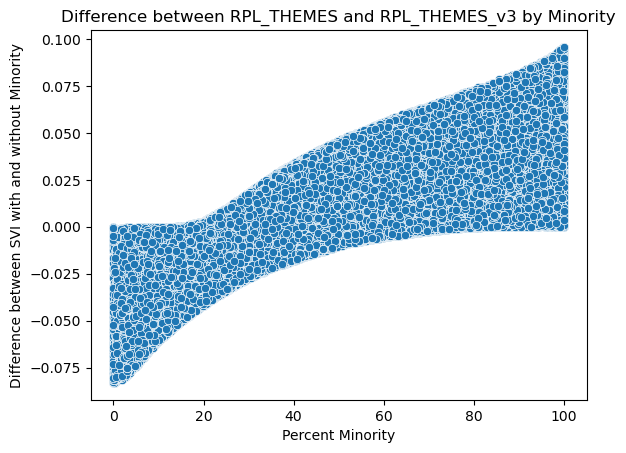

In [87]:
# scatter difference by EP_MINRTY
sns.scatterplot(x='EP_MINRTY', y='diff_RPL_THEMES', data=cdc_df)
plt.title("Difference between RPL_THEMES and RPL_THEMES_v3 by Minority")
plt.xlabel("Percent Minority")
plt.ylabel("Difference between SVI with and without Minority")
plt.show()


In [88]:
# Create 4 percentile breaks for EP_MINRTY and get bin edges
cdc_df['EP_MINRTY_quartile'], bins = pd.qcut(cdc_df['EP_MINRTY'], q=4, retbins=True)

# Label the quartiles by their range
cdc_df['EP_MINRTY_quartile_label'] = pd.qcut(cdc_df['EP_MINRTY'], q=4, 
                                             labels=[f'{round(bins[i], 2)}% - {round(bins[i+1], 2)}%'
                                                     for i in range(len(bins)-1)])

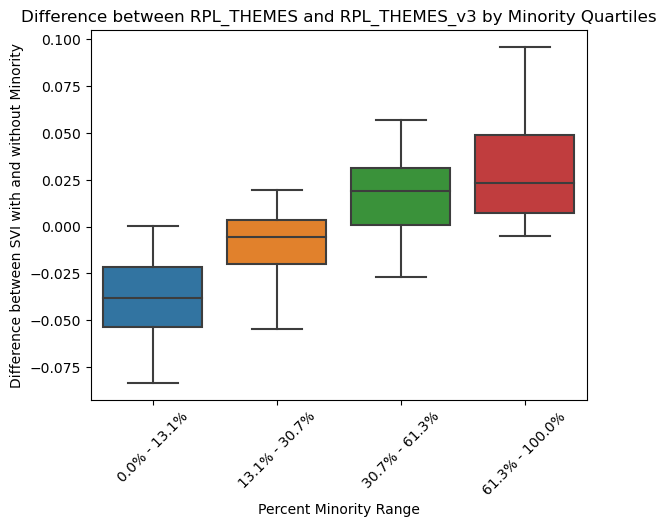

In [89]:
# Create a box plot with EP_MINRTY split into labeled quartiles
sns.boxplot(x='EP_MINRTY_quartile_label', y='diff_RPL_THEMES', data=cdc_df)
plt.title("Difference between RPL_THEMES and RPL_THEMES_v3 by Minority Quartiles")
plt.xlabel("Percent Minority Range")
plt.ylabel("Difference between SVI with and without Minority")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

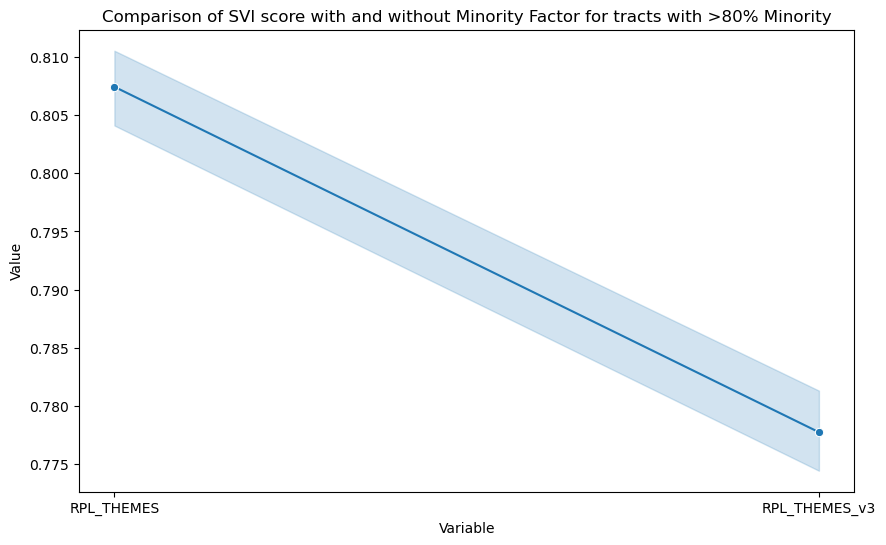

In [90]:
# what happens for high minroity areas
condition = cdc_df['EP_MINRTY'] > 80

# select observations
high_minority = cdc_df[condition].copy()

# Melt the dataframe to make it easier to plot both RPL_THEMES and RPL_THEMES_v3
melted_df = high_minority.melt(id_vars=['FIPS'], value_vars=['RPL_THEMES', 'RPL_THEMES_v3'], 
                        var_name='Variable', value_name='Value')

# Plot the data using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=melted_df, x='Variable', y='Value', marker="o", linewidth=1.5)

# Add title and labels
plt.title("Comparison of SVI score with and without Minority Factor for tracts with >80% Minority")
plt.xlabel("Variable")
plt.ylabel("Value")
plt.xticks([0, 1], ['RPL_THEMES', 'RPL_THEMES_v3'])

# Display the plot
plt.show()

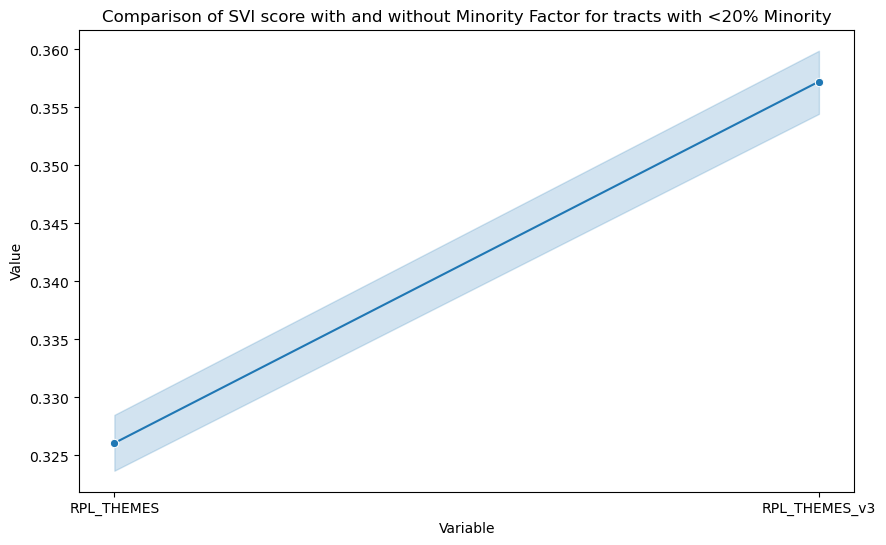

In [91]:
# what happens for high minroity areas
condition = cdc_df['EP_MINRTY'] < 20

# select observations
high_minority = cdc_df[condition].copy()

# Melt the dataframe to make it easier to plot both RPL_THEMES and RPL_THEMES_v3
melted_df = high_minority.melt(id_vars=['FIPS'], value_vars=['RPL_THEMES', 'RPL_THEMES_v3'], 
                        var_name='Variable', value_name='Value')

# Plot the data using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=melted_df, x='Variable', y='Value', marker="o", linewidth=1.5)

# Add title and labels
plt.title("Comparison of SVI score with and without Minority Factor for tracts with <20% Minority")
plt.xlabel("Variable")
plt.ylabel("Value")
plt.xticks([0, 1], ['RPL_THEMES', 'RPL_THEMES_v3'])

# Display the plot
plt.show()

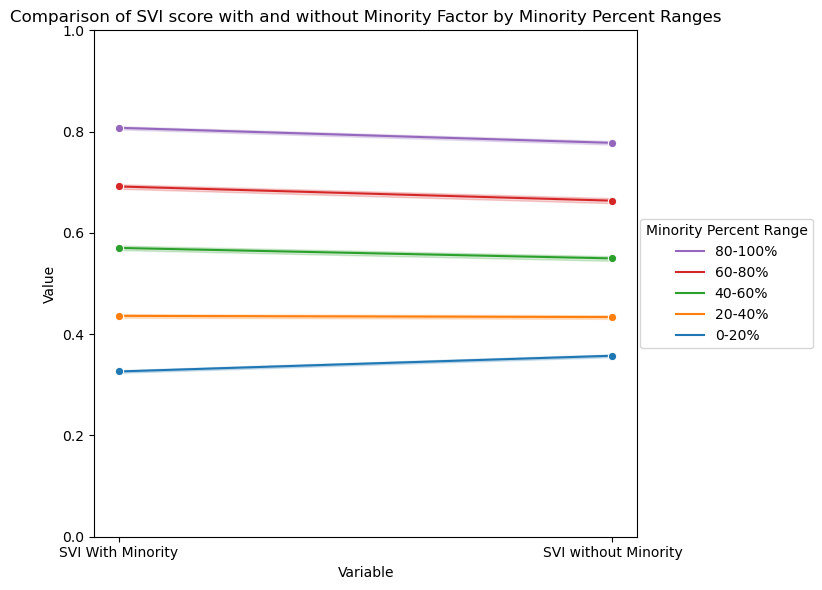

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the bins and labels for the ranges
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']


# Bin the 'EP_MINRTY' column into the defined ranges
cdc_df['Minority_Group'] = pd.cut(cdc_df['EP_MINRTY'], bins=bins, labels=labels, include_lowest=True)

# Melt the dataframe to make it easier to plot both RPL_THEMES and RPL_THEMES_v3
melted_df = cdc_df.melt(id_vars=['FIPS', 'Minority_Group'], 
                        value_vars=['RPL_THEMES', 'RPL_THEMES_v3'], 
                        var_name='Variable', value_name='Value')

# Plot the data using Seaborn
plt.figure(figsize=(8, 6))
sns.lineplot(data=melted_df, x='Variable', y='Value', hue='Minority_Group', marker="o", linewidth=1.5)

# Add title and labels
plt.title("Comparison of SVI score with and without Minority Factor by Minority Percent Ranges")
plt.xlabel("Variable")
plt.ylabel("Value")
plt.ylim(0, 1)
plt.xticks([0, 1], ['SVI With Minority', 'SVI without Minority'])

# Get the current legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Reverse the order of the handles and labels
handles = handles[::-1]
labels = labels[::-1]

# Apply the reversed legend
plt.legend(handles, labels, title='Minority Percent Range', loc='best')

# Adjust the legend to be outside the plot and reverse the order
plt.legend(handles, labels, title='Minority Percent Range', loc='center left', 
           bbox_to_anchor=(1, 0.5), borderaxespad=0.2)

# Adjust layout to make room for the legend
plt.tight_layout()

# Display the plot
plt.show()